# 🔬 PCOS Detection menggunakan Deep Learning (MobileNetV2)
### Analisis Citra Ultrasound Ovarium dengan Preprocessing CLAHE, Noise Reduction & Normalisasi

> **🔧 Revisi Diterapkan:** Tahap 1 (Preprocessing Order) · Tahap 2 (preprocess_input) · Tahap 3 (Grad-CAM otomatis) · Tahap 4 (Fine-tuning 100 layer) · Tahap 5 (ROI Crop opsional) · Tahap 6 (Grad-CAM++)

**Dataset**: PCOS Detection Using Ultrasound Images (Kaggle) — 3856 citra  
**Arsitektur**: MobileNetV2 (Transfer Learning)  
**Kelas**: `infected` (PCOS) vs `notinfected` (Normal)

---


## 1. Instalasi & Import Library

In [1]:
# Install dependencies jika belum ada
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["tensorflow", "opencv-python", "scikit-learn", "matplotlib",
            "seaborn", "numpy", "pandas", "Pillow", "imagehash", "tqdm"]
for pkg in required:
    try:
        __import__(pkg.replace("-", "_").split("==")[0])
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

print("✅ Semua library tersedia!")


Installing opencv-python...



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Installing scikit-learn...



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Installing Pillow...
✅ Semua library tersedia!



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, shutil, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
import imagehash
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint, TensorBoard)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU config ───────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🚀 GPU ditemukan: {len(gpus)} device(s)")
else:
    print("⚠️  Tidak ada GPU — menggunakan CPU")

print(f"TensorFlow version: {tf.__version__}")


⚠️  Tidak ada GPU — menggunakan CPU
TensorFlow version: 2.19.0


## 2. Konfigurasi Path & Hyperparameter

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  KONFIGURASI — Sesuaikan BASE_DIR dengan lokasi dataset Anda
# ═══════════════════════════════════════════════════════════════════════════
BASE_DIR     = Path('/Users/wandaaulialarasati/Downloads/pcos')
TRAIN_DIR    = BASE_DIR / "train"
TEST_DIR     = BASE_DIR / "test"
VAL_DIR      = BASE_DIR / "val"          # akan dibuat otomatis

CLASSES      = ["infected", "notinfected"]
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS_WARM  = 10    # fase warm-up (head saja)
EPOCHS_FINE  = 30    # fase fine-tuning
VAL_SPLIT    = 0.2   # 20% dari train -> validasi

# [TAHAP 4] Unfreeze ~100 layer terakhir MobileNetV2 (lebih dalam dari sebelumnya).
# MobileNetV2 memiliki ~155 layer; freeze 55 pertama = unfreeze 100 terakhir.
# Ini membuat backbone lebih adaptif terhadap citra USG.
UNFREEZE_FROM_LAYER = 55   # DIUBAH: dari 100 -> 55 (unfreeze 100 layer terakhir)

MODEL_SAVE_PATH = "pcos_mobilenetv2_best.keras"

# Validasi direktori
assert TRAIN_DIR.exists(), f"Folder train tidak ditemukan: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Folder test tidak ditemukan: {TEST_DIR}"
print("Path dataset valid")
print(f"   Train : {TRAIN_DIR}")
print(f"   Test  : {TEST_DIR}")
print(f"   Val   : {VAL_DIR} (akan dibuat otomatis)")


Path dataset valid
   Train : /Users/wandaaulialarasati/Downloads/pcos/train
   Test  : /Users/wandaaulialarasati/Downloads/pcos/test
   Val   : /Users/wandaaulialarasati/Downloads/pcos/val (akan dibuat otomatis)


## 3. Deteksi & Penghapusan Data Duplikat

Menggunakan **perceptual hash (pHash)** untuk mendeteksi citra yang secara visual
identik meskipun metadata-nya berbeda.


In [4]:
def get_image_hash(path: Path, hash_size: int = 16) -> str:
    """Kembalikan perceptual hash (pHash) dari sebuah citra."""
    try:
        img = Image.open(path).convert("L")   # grayscale
        return str(imagehash.phash(img, hash_size=hash_size))
    except Exception:
        return None


def detect_and_remove_duplicates(root_dir: Path, threshold: int = 5,
                                  dry_run: bool = False) -> dict:
    """
    Scan semua citra di bawah root_dir, kelompokkan berdasarkan pHash,
    hapus duplikat (sisakan satu per kelompok).

    Parameters
    ----------
    threshold : int
        Jarak Hamming maksimum agar dua citra dianggap duplikat (0 = identik persis).
    dry_run   : bool
        Jika True, hanya cetak laporan tanpa menghapus file.

    Returns
    -------
    dict dengan statistik.
    """
    EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    all_files = [p for p in root_dir.rglob("*") if p.suffix.lower() in EXT]
    print(f"📂 Total citra ditemukan di '{root_dir.name}': {len(all_files)}")

    hashes: dict[str, Path] = {}   # hash → path pertama yang ditemukan
    duplicates: list[Path] = []

    for fpath in tqdm(all_files, desc="Hashing citra"):
        h = get_image_hash(fpath)
        if h is None:
            continue

        # Cek apakah hash mirip dengan yang sudah ada (threshold Hamming)
        found_dup = False
        for existing_h, existing_path in list(hashes.items()):
            dist = imagehash.hex_to_hash(h) - imagehash.hex_to_hash(existing_h)
            if dist <= threshold:
                duplicates.append(fpath)
                found_dup = True
                break
        if not found_dup:
            hashes[h] = fpath

    print(f"\n🔍 Hasil deteksi duplikat (threshold={threshold}):")
    print(f"   Citra unik   : {len(hashes)}")
    print(f"   Citra duplikat: {len(duplicates)}")

    if duplicates:
        print("\n🗑️  File duplikat yang akan dihapus:")
        for p in duplicates[:10]:
            print(f"   {p}")
        if len(duplicates) > 10:
            print(f"   ... dan {len(duplicates)-10} file lainnya")

        if not dry_run:
            for p in duplicates:
                p.unlink()
            print(f"\n✅ {len(duplicates)} file duplikat berhasil dihapus!")
        else:
            print("\n⚠️  DRY RUN — tidak ada file yang dihapus.")
    else:
        print("✅ Tidak ada duplikat ditemukan.")

    return {"unique": len(hashes), "duplicates": len(duplicates),
            "removed": 0 if dry_run else len(duplicates)}



def cross_dedup_test_vs_train(train_dir: Path, test_dir: Path,
                               threshold: int = 5, dry_run: bool = False) -> dict:
    """
    Hapus citra dari test yang merupakan near-duplicate dari citra train.
    Mencegah data leakage lintas split (kebocoran train → test).

    Parameters
    ----------
    threshold : int  Jarak Hamming maksimum (0 = identik persis).
    dry_run   : bool Jika True, hanya cetak laporan tanpa menghapus file.
    """
    EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    # 1. Bangun indeks hash dari seluruh train set
    train_files = [p for p in train_dir.rglob("*") if p.suffix.lower() in EXT]
    print(f"📂 Membangun hash index dari {len(train_files)} citra train...")
    train_hashes: dict[str, Path] = {}
    for p in tqdm(train_files, desc="Hash train"):
        h = get_image_hash(p)
        if h is not None:
            train_hashes[h] = p
    train_hash_objs = {h: imagehash.hex_to_hash(h) for h in train_hashes}

    # 2. Periksa setiap citra test terhadap indeks train
    test_files = [p for p in test_dir.rglob("*") if p.suffix.lower() in EXT]
    print(f"📂 Memeriksa {len(test_files)} citra test terhadap {len(train_hashes)} hash train...")

    leaked: list[Path] = []
    for p in tqdm(test_files, desc="Cek kebocoran"):
        h = get_image_hash(p)
        if h is None:
            continue
        h_obj = imagehash.hex_to_hash(h)
        for train_h_obj in train_hash_objs.values():
            if h_obj - train_h_obj <= threshold:
                leaked.append(p)
                break

    print(f"\n🔍 Citra test yang near-duplicate dengan train (threshold={threshold}): {len(leaked)}")
    if leaked:
        for p in leaked[:10]:
            print(f"   {p}")
        if len(leaked) > 10:
            print(f"   ... dan {len(leaked) - 10} lainnya")
        if not dry_run:
            for p in leaked:
                p.unlink()
            print(f"\n✅ {len(leaked)} citra bocor berhasil dihapus dari test set.")
        else:
            print("\n⚠️  DRY RUN — tidak ada file yang dihapus.")
    else:
        print("✅ Tidak ada kebocoran data antara train dan test.")

    return {"leaked": len(leaked), "removed": 0 if dry_run else len(leaked)}

# Jalankan pada train dan test
print("=" * 60)
print("SCAN FOLDER TRAIN")
print("=" * 60)
stats_train = detect_and_remove_duplicates(TRAIN_DIR, threshold=5, dry_run=False)

print("\n" + "=" * 60)
print("SCAN FOLDER TEST")
print("=" * 60)
stats_test  = detect_and_remove_duplicates(TEST_DIR,  threshold=5, dry_run=False)
print("\n" + "=" * 60)
print("SCAN LINTAS-SET: TRAIN ↔ TEST  (data leakage check)")
print("=" * 60)
stats_cross = cross_dedup_test_vs_train(TRAIN_DIR, TEST_DIR, threshold=5, dry_run=False)


SCAN FOLDER TRAIN
📂 Total citra ditemukan di 'train': 1305


Hashing citra: 100%|██████████████████████| 1305/1305 [01:18<00:00, 16.65it/s]



🔍 Hasil deteksi duplikat (threshold=5):
   Citra unik   : 1305
   Citra duplikat: 0
✅ Tidak ada duplikat ditemukan.

SCAN FOLDER TEST
📂 Total citra ditemukan di 'test': 288


Hashing citra: 100%|████████████████████████| 288/288 [00:04<00:00, 66.59it/s]



🔍 Hasil deteksi duplikat (threshold=5):
   Citra unik   : 288
   Citra duplikat: 0
✅ Tidak ada duplikat ditemukan.

SCAN LINTAS-SET: TRAIN ↔ TEST  (data leakage check)
📂 Membangun hash index dari 1305 citra train...


Hash train: 100%|████████████████████████| 1305/1305 [00:02<00:00, 452.12it/s]


📂 Memeriksa 288 citra test terhadap 1305 hash train...


Cek kebocoran: 100%|███████████████████████| 288/288 [00:01<00:00, 228.45it/s]


🔍 Citra test yang near-duplicate dengan train (threshold=5): 0
✅ Tidak ada kebocoran data antara train dan test.


## 4. Pembuatan Folder Validasi Otomatis

20% citra dari setiap kelas di folder **train** dipindahkan ke folder **val**,
mempertahankan struktur `infected / notinfected`.


In [5]:
def create_validation_set(train_dir: Path, val_dir: Path,
                           classes: list, val_ratio: float = 0.2,
                           seed: int = 42) -> pd.DataFrame:
    """
    Pindahkan val_ratio citra dari setiap kelas di train_dir ke val_dir.
    Hanya dijalankan jika val_dir belum ada atau kosong.
    """
    EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    records = []

    if val_dir.exists() and any(val_dir.rglob("*.*")):
        print(f"⚠️  Folder validasi sudah ada dan tidak kosong — dilewati.")
        # Hitung saja
        for cls in classes:
            n = len(list((val_dir / cls).rglob("*")))
            records.append({"class": cls, "val_count": n})
        return pd.DataFrame(records)

    np.random.seed(seed)
    for cls in classes:
        src = train_dir / cls
        dst = val_dir   / cls
        dst.mkdir(parents=True, exist_ok=True)

        all_imgs = [p for p in src.iterdir() if p.suffix.lower() in EXT]
        np.random.shuffle(all_imgs)
        n_val = int(len(all_imgs) * val_ratio)
        val_imgs = all_imgs[:n_val]

        for img_path in val_imgs:
            shutil.move(str(img_path), str(dst / img_path.name))

        records.append({
            "class"      : cls,
            "total_train": len(all_imgs),
            "moved_to_val": n_val,
            "remaining_train": len(all_imgs) - n_val,
        })
        print(f"  [{cls}]  Total: {len(all_imgs)}  →  Val: {n_val}  |  Train tersisa: {len(all_imgs)-n_val}")

    df = pd.DataFrame(records)
    print("\n✅ Folder validasi berhasil dibuat!")
    print(f"   Path: {val_dir}")
    return df

print("Membuat split validasi...")
split_df = create_validation_set(TRAIN_DIR, VAL_DIR, CLASSES, VAL_SPLIT, SEED)
print()
print(split_df.to_string(index=False))


Membuat split validasi...
⚠️  Folder validasi sudah ada dan tidak kosong — dilewati.

      class  val_count
   infected        131
notinfected        194


## 5. Exploratory Data Analysis (EDA)

Distribusi Dataset:
       infected  notinfected  Total
Train       528          777   1305
Val         131          194    325
Test        117          171    288


KeyError: "['Total'] not found in axis"

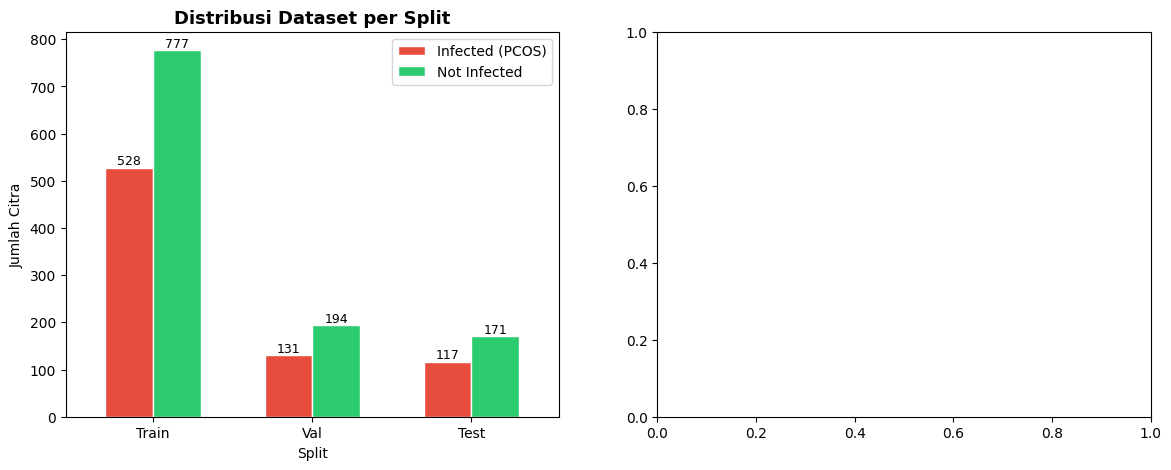

In [6]:
def count_images(base: Path, classes: list) -> dict:
    EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return {cls: len([p for p in (base/cls).rglob("*") if p.suffix.lower() in EXT])
            for cls in classes}

counts = {
    "Train": count_images(TRAIN_DIR, CLASSES),
    "Val"  : count_images(VAL_DIR,   CLASSES),
    "Test" : count_images(TEST_DIR,  CLASSES),
}

df_counts = pd.DataFrame(counts).T
df_counts["Total"] = df_counts.sum(axis=1)
print("Distribusi Dataset:")
print(df_counts)

# ── Visualisasi distribusi ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#E74C3C", "#2ECC71"]

# Bar chart per split
df_counts.drop("Total", axis=1).plot(kind="bar", ax=axes[0],
    color=colors, edgecolor="white", width=0.6)
axes[0].set_title("Distribusi Dataset per Split", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Split"); axes[0].set_ylabel("Jumlah Citra")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Infected (PCOS)", "Not Infected"])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

# Pie chart total
total_per_class = df_counts.drop("Total").sum()
axes[1].pie(total_per_class, labels=["Infected (PCOS)", "Not Infected"],
            colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporsi Total Kelas", fontsize=13, fontweight="bold")

plt.suptitle("Distribusi Dataset PCOS Ultrasound", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik distribusi disimpan: eda_distribution.png")


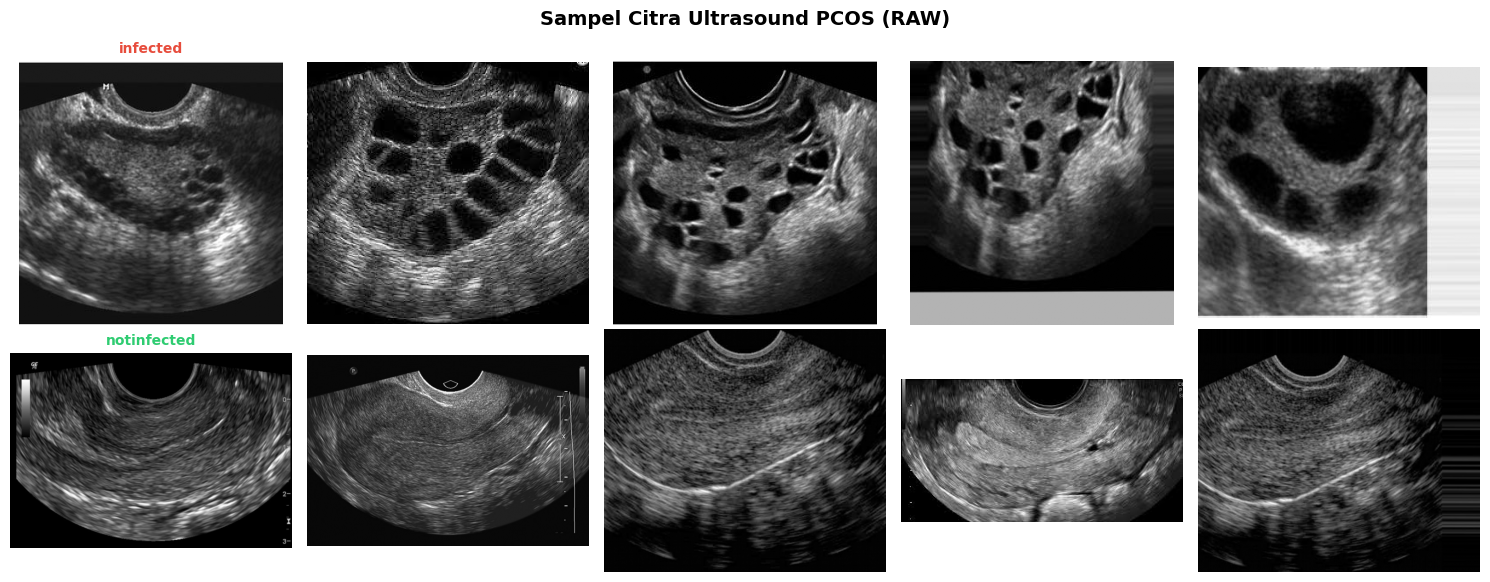

In [7]:
def show_sample_images(train_dir: Path, classes: list, n_per_class: int = 5):
    """Tampilkan sampel citra RAW (sebelum preprocessing)."""
    EXT = {".jpg", ".jpeg", ".png", ".bmp"}
    fig, axes = plt.subplots(len(classes), n_per_class,
                              figsize=(n_per_class * 3, len(classes) * 3))
    colors = ["#E74C3C", "#2ECC71"]

    for r, cls in enumerate(classes):
        imgs = sorted((train_dir / cls).glob("*"))
        imgs = [p for p in imgs if p.suffix.lower() in EXT][:n_per_class]
        for c, img_path in enumerate(imgs):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            axes[r, c].imshow(img, cmap="gray")
            axes[r, c].set_title(cls if c == 0 else "", fontweight="bold",
                                  color=colors[r], fontsize=10)
            axes[r, c].axis("off")

    plt.suptitle("Sampel Citra Ultrasound PCOS (RAW)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("sample_images_raw.png", dpi=150, bbox_inches="tight")
    plt.show()

show_sample_images(TRAIN_DIR, CLASSES, n_per_class=5)


## 5b. [TAHAP 5] ROI Crop — Isolasi Area Ovarium (Opsional tapi Sangat Disarankan)

Dengan memotong area ovarium sebelum training, model dipaksa untuk hanya melihat
folikel — bukan background atau watermark USG — sehingga Grad-CAM lebih fokus.

**Dua strategi tersedia:**
1. **Crop Otomatis** — Deteksi oval/elips terbesar (pendekatan berbasis kontur).
2. **Crop Manual** — Tentukan bounding box tetap jika anatomi konsisten.

> ⚠️ Aktifkan `USE_ROI_CROP = True` dan sesuaikan parameter jika dataset mendukungnya.


[TAHAP 5] USE_ROI_CROP = False
Menampilkan preview ROI crop...


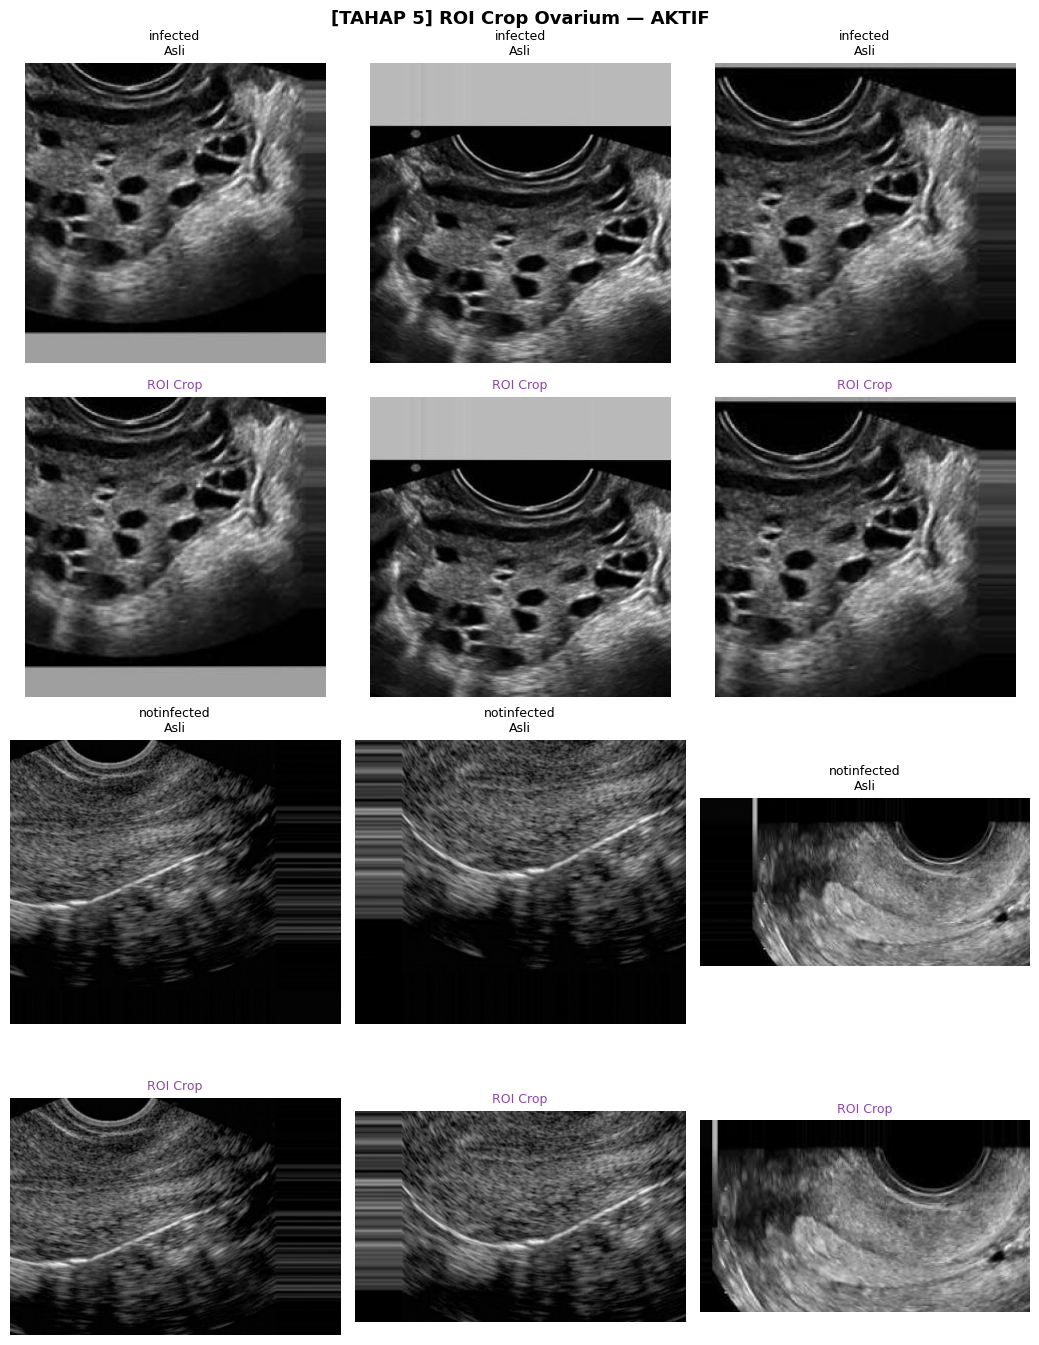

✅ Preview ROI crop selesai. Aktifkan USE_ROI_CROP=True untuk pakai saat training.


In [8]:
# ─── [TAHAP 5] ROI Crop Ovarium ───────────────────────────────────────────────
# Toggle: set True untuk mengaktifkan ROI crop sebelum masuk ke preprocessing.
USE_ROI_CROP = False   # ← Ubah ke True jika ingin mengaktifkan

# Koordinat crop manual (x, y, w, h) dalam pixel — sesuaikan dengan dataset Anda.
# Jika USE_ROI_CROP=True dan MANUAL_ROI tidak None, crop manual digunakan.
# Jika None, crop otomatis berbasis kontur dijalankan.
MANUAL_ROI = None   # contoh: (50, 30, 420, 380)


def auto_crop_ovarium(gray_img: np.ndarray, pad: int = 10) -> tuple:
    """
    Deteksi area ovarium secara otomatis menggunakan kontur terbesar.
    Mengembalikan (x, y, w, h) bounding box, atau None jika gagal.
    Strategi: CLAHE ringan → Threshold Otsu → kontur terbesar.
    """
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray_img)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    H, W = gray_img.shape
    x = max(0, x - pad);  y = max(0, y - pad)
    w = min(W - x, w + 2*pad);  h = min(H - y, h + 2*pad)
    return (x, y, w, h)


def crop_ovarium(gray_img: np.ndarray, manual_roi: tuple = None) -> np.ndarray:
    """
    Crop area ovarium dari citra grayscale.
    Jika USE_ROI_CROP=False → bypass (kembalikan citra asli).
    Jika manual_roi diberikan → crop manual.
    Jika None → crop otomatis. Fallback ke asli jika gagal.
    """
    if not USE_ROI_CROP:
        return gray_img
    roi = manual_roi if manual_roi is not None else auto_crop_ovarium(gray_img)
    if roi is None:
        return gray_img
    x, y, w, h = roi
    return gray_img[y:y+h, x:x+w]


def visualize_roi_crop(train_dir: Path, classes: list, n: int = 3):
    """Bandingkan citra asli vs hasil ROI crop."""    
    EXT = {".jpg", ".jpeg", ".png"}
    fig, axes = plt.subplots(len(classes) * 2, n,
                              figsize=(n * 3.5, len(classes) * 7))
    row = 0
    for cls in classes:
        imgs = [p for p in (train_dir/cls).glob("*")
                if p.suffix.lower() in EXT][:n]
        for col, img_path in enumerate(imgs):
            raw  = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            crop = crop_ovarium(raw, MANUAL_ROI)
            axes[row,   col].imshow(raw,  cmap="gray")
            axes[row,   col].set_title(f"{cls}\nAsli", fontsize=9)
            axes[row,   col].axis("off")
            axes[row+1, col].imshow(crop, cmap="gray")
            axes[row+1, col].set_title("ROI Crop", fontsize=9, color="#8E44AD")
            axes[row+1, col].axis("off")
        row += 2
    status = "AKTIF" if USE_ROI_CROP else "NON-AKTIF (USE_ROI_CROP=False)"
    plt.suptitle(f"[TAHAP 5] ROI Crop Ovarium — {status}",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("roi_crop_preview.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"[TAHAP 5] USE_ROI_CROP = {USE_ROI_CROP}")
print("Menampilkan preview ROI crop...")
_prev = USE_ROI_CROP;  USE_ROI_CROP = True
visualize_roi_crop(TRAIN_DIR, CLASSES, n=3)
USE_ROI_CROP = _prev
print("✅ Preview ROI crop selesai. Aktifkan USE_ROI_CROP=True untuk pakai saat training.")


## 6. Fungsi Preprocessing Citra

Pipeline preprocessing:
1. **CLAHE** — Contrast Limited Adaptive Histogram Equalization
2. **Gaussian / Median Filter** — Noise Reduction
3. **Normalisasi** — Piksel ke rentang [0, 1]
4. **Resize** — 224 × 224 piksel


In [9]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess


def apply_clahe(gray_img: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid: tuple = (8, 8)) -> np.ndarray:
    """Terapkan CLAHE pada citra grayscale."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    return clahe.apply(gray_img)


def apply_noise_reduction(gray_img: np.ndarray,
                           method: str = "median",
                           ksize: int = 3) -> np.ndarray:
    """
    Kurangi noise pada citra grayscale.
    [TAHAP 1] Default diubah ke 'median' ksize=3 (dari 'gaussian' ksize=5).
    Median filter lebih baik mempertahankan tepi folikel dibanding Gaussian.
    method : 'median' | 'bilateral' | 'gaussian'
    """
    if method == "median":
        return cv2.medianBlur(gray_img, ksize)
    elif method == "bilateral":
        return cv2.bilateralFilter(gray_img, d=9, sigmaColor=75, sigmaSpace=75)
    elif method == "gaussian":
        return cv2.GaussianBlur(gray_img, (ksize, ksize), 0)
    else:
        raise ValueError(f"Method tidak dikenal: {method}")


def enhance_follicles(gray_img: np.ndarray,
                      kernel_size: int = 11,
                      edge_weight: float = 0.25,
                      morph_weight: float = 0.40) -> np.ndarray:
    """
    Follicle Enhancement khusus USG ovarium.

    Pipeline:
      BlackHat Morphology  → menonjolkan folikel (struktur gelap)
           ↓
      Laplacian Edge       → mendeteksi tepi folikel
           ↓
      Weighted Fusion      → original + blackhat + laplacian
    """
    # Black Hat — menonjolkan struktur gelap (folikel) di atas latar terang
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray_img, cv2.MORPH_BLACKHAT, kernel)

    # Laplacian Edge — mendeteksi tepi folikel
    lap = cv2.Laplacian(gray_img, cv2.CV_32F, ksize=3)
    lap = cv2.convertScaleAbs(lap)

    # Weighted Fusion: original + blackhat + laplacian edges
    enhanced = cv2.addWeighted(gray_img, 1.0, blackhat, morph_weight, 0)
    enhanced = cv2.addWeighted(enhanced,  1.0, lap,      edge_weight,  0)
    enhanced = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)

    return enhanced.astype(np.uint8)


def preprocess_image(img_path,
                     target_size: tuple = (224, 224),
                     clahe_clip: float = 2.0,
                     noise_method: str = "median",
                     noise_ksize: int = 3,
                     for_display: bool = False) -> np.ndarray:
    """
    Pipeline preprocessing satu citra — Revisi Tahap 1, 2, & 5.

    Urutan: Baca → [ROI Crop] → CLAHE → Median → Follicle Enhancement → Resize → preprocess_input
    [TAHAP 1] CLAHE & filter dikerjakan pada resolusi ASLI sebelum resize.
    [TAHAP 2] mobilenet_preprocess() menggantikan normalisasi manual /255.
    [TAHAP 5] crop_ovarium() dipanggil opsional sebelum CLAHE.

    Parameter
    ----------
    for_display : bool
        True  → kembalikan uint8 [0,255] RGB untuk imshow().
        False → float32 [-1,1] untuk model (via mobilenet_preprocess).
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Tidak dapat membaca: {img_path}")

    # [TAHAP 5] Step 0: ROI Crop opsional (bypass jika USE_ROI_CROP=False)
    img = crop_ovarium(img, MANUAL_ROI)

    # [TAHAP 1] Step 1: CLAHE pada resolusi asli
    img = apply_clahe(img, clip_limit=clahe_clip)

    # [TAHAP 1] Step 2: Noise reduction pada resolusi asli
    img = apply_noise_reduction(img, method=noise_method, ksize=noise_ksize)

    # Step 3: Follicle Enhancement — BlackHat + Laplacian fusion
    img = enhance_follicles(img, kernel_size=11, edge_weight=0.25, morph_weight=0.40)

    # [TAHAP 1] Step 4: Resize SETELAH semua preprocessing
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    # Step 5: Konversi ke RGB (MobileNetV2 butuh 3 channel)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    if for_display:
        return img_rgb  # uint8 [0,255]

    # [TAHAP 2] Step 6: preprocess_input() MobileNetV2 — range [-1, 1]
    return mobilenet_preprocess(img_rgb.astype(np.float32))


print("✅ Fungsi preprocessing terdefinisi (Tahap 1, 2, 5 diterapkan).")
print("   ✔ Urutan: [ROI Crop] → CLAHE → MedianBlur → Follicle Enhancement → Resize → preprocess_input()")
print("   ✔ Noise method default: MedianBlur(3x3)")
print("   ✔ Normalisasi: mobilenet_preprocess() — bukan manual /255")
print("   ✔ Follicle Enhancement: BlackHat + Laplacian fusion aktif")


✅ Fungsi preprocessing terdefinisi (Tahap 1, 2, 5 diterapkan).
   ✔ Urutan: [ROI Crop] → CLAHE → MedianBlur → Follicle Enhancement → Resize → preprocess_input()
   ✔ Noise method default: MedianBlur(3x3)
   ✔ Normalisasi: mobilenet_preprocess() — bukan manual /255
   ✔ Follicle Enhancement: BlackHat + Laplacian fusion aktif


### Visualisasi Perbandingan Sebelum & Sesudah Preprocessing

In [10]:
def preview_follicle_enhancement(train_dir,
                                 classes,
                                 n=3):

    EXT = {".jpg",".jpeg",".png"}

    fig,axes = plt.subplots(
        len(classes),
        n*2,
        figsize=(n*5,len(classes)*4)
    )

    for r,cls in enumerate(classes):

        imgs=[
            p for p in (train_dir/cls).glob("*")
            if p.suffix.lower() in EXT
        ][:n]

        for c,p in enumerate(imgs):

            img=cv2.imread(
                str(p),
                cv2.IMREAD_GRAYSCALE
            )

            img=apply_clahe(img)

            img=apply_noise_reduction(img)

            enh=enhance_follicles(img)

            axes[r,c*2].imshow(img,cmap='gray')
            axes[r,c*2].set_title(
                f"{cls}\nOriginal"
            )
            axes[r,c*2].axis("off")

            axes[r,c*2+1].imshow(
                enh,
                cmap='gray'
            )
            axes[r,c*2+1].set_title(
                "Follicle Enhanced"
            )
            axes[r,c*2+1].axis("off")

    plt.tight_layout()

    plt.show()

## 7. Custom Data Generator dengan Preprocessing

In [11]:
class PCOSDataGenerator(keras.utils.Sequence):
    """
    Generator Keras yang membaca citra dari disk dan menerapkan
    pipeline preprocessing + augmentasi (opsional) on-the-fly.
    [TAHAP 2] preprocess_image() sudah mengembalikan [-1,1] via
              mobilenet_preprocess(). Tidak perlu *2.0-1.0 manual.
    """

    def __init__(self, data_dir: Path, classes: list,
                 img_size: tuple = (224, 224),
                 batch_size: int = 32,
                 augment: bool = False,
                 shuffle: bool = True,
                 seed: int = 42):
        self.img_size    = img_size
        self.batch_size  = batch_size
        self.augment     = augment
        self.shuffle     = shuffle
        self.classes     = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.rng         = np.random.default_rng(seed)

        EXT = {".jpg", ".jpeg", ".png", ".bmp"}
        self.samples = []
        for cls in classes:
            for p in (data_dir / cls).glob("*"):
                if p.suffix.lower() in EXT:
                    self.samples.append((p, self.class_to_idx[cls]))

        self.indexes = np.arange(len(self.samples))
        if self.shuffle:
            self.rng.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = [self.samples[i] for i in batch_idx]

        X = np.zeros((len(batch), *self.img_size, 3), dtype=np.float32)
        y = np.zeros(len(batch), dtype=np.float32)

        for i, (path, label) in enumerate(batch):
            # [TAHAP 2] for_display=False -> preprocess_image() mengembalikan [-1,1]
            # via mobilenet_preprocess(). Tidak perlu *2.0-1.0 manual.
            img_pp = preprocess_image(path, target_size=self.img_size, for_display=False)
            if self.augment:
                img_pp = self._augment(img_pp)
            X[i] = img_pp
            y[i] = label

        return X, y

    def _augment(self, img: np.ndarray) -> np.ndarray:
        """Augmentasi ringan untuk citra medis (range [-1,1])."""        
        if self.rng.random() > 0.5:
            img = img[:, ::-1, :]
        if self.rng.random() > 0.5:
            img = img[::-1, :, :]
        angle = self.rng.uniform(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h),
                              flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT)
        factor = self.rng.uniform(0.9, 1.1)
        img = np.clip(img * factor, -1.0, 1.0).astype(np.float32)
        if self.rng.random() > 0.7:
            noise = self.rng.normal(0, 0.01, img.shape).astype(np.float32)
            img   = np.clip(img + noise, -1.0, 1.0)
        return img

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indexes)

    @property
    def class_weights(self) -> dict:
        """Hitung class weight untuk menangani ketidakseimbangan kelas."""        
        from collections import Counter
        label_counts = Counter(label for _, label in self.samples)
        total = len(self.samples)
        weights = {k: total / (len(label_counts) * v)
                   for k, v in label_counts.items()}
        return weights


# Buat generator
train_gen = PCOSDataGenerator(TRAIN_DIR, CLASSES, IMG_SIZE, BATCH_SIZE,
                               augment=True, shuffle=True)
val_gen   = PCOSDataGenerator(VAL_DIR,   CLASSES, IMG_SIZE, BATCH_SIZE,
                               augment=False, shuffle=False)
test_gen  = PCOSDataGenerator(TEST_DIR,  CLASSES, IMG_SIZE, BATCH_SIZE,
                               augment=False, shuffle=False)

cw = train_gen.class_weights
print(f"Generator berhasil dibuat")
print(f"   Train batches : {len(train_gen)}  ({len(train_gen.samples)} citra)")
print(f"   Val   batches : {len(val_gen)}   ({len(val_gen.samples)} citra)")
print(f"   Test  batches : {len(test_gen)}  ({len(test_gen.samples)} citra)")
print(f"   Class weights : {cw}")


Generator berhasil dibuat
   Train batches : 41  (1305 citra)
   Val   batches : 11   (325 citra)
   Test  batches : 9  (288 citra)
   Class weights : {0: 1.2357954545454546, 1: 0.8397683397683398}


## 8. Arsitektur Model — MobileNetV2 + Custom Head

Strategi **Two-Stage Training**:
1. **Warm-up** — Hanya melatih custom classification head, backbone dibekukan.
2. **Fine-tuning** — Unfreeze layer atas MobileNetV2, latih dengan LR sangat kecil.


In [13]:
def build_model(img_size: tuple = (224, 224),
                dropout_rate: float = 0.2,
                unfreeze_from: int = 100) -> tuple[Model, Model]:
    """
    MobileNetV2 dengan classifier minimal.
    Tujuan:
    - Mengurangi overfitting
    - Meningkatkan interpretabilitas Grad-CAM
    """

    input_tensor = keras.Input(
        shape=(*img_size, 3),
        name="input_image"
    )

    # ======================================================
    # Backbone
    # ======================================================

    base = MobileNetV2(
        input_tensor=input_tensor,
        include_top=False,
        weights="imagenet",
        alpha=1.0
    )

    # Freeze seluruh backbone pada tahap awal
    base.trainable = False

    # ======================================================
    # Classification Head
    # ======================================================

    x = base.output

    x = layers.GlobalAveragePooling2D(
        name="gap"
    )(x)

    x = layers.Dropout(
        dropout_rate,
        name="dropout"
    )(x)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )(x)

    # ======================================================
    # Model
    # ======================================================

    model = Model(
        inputs=input_tensor,
        outputs=output,
        name="PCOS_MobileNetV2"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model, base


# ======================================================
# Build Model
# ======================================================

model, base_model = build_model(
    IMG_SIZE,
    dropout_rate=0.2,
    unfreeze_from=UNFREEZE_FROM_LAYER
)

model.summary(line_length=90)

print(f"\nTotal parameters      : {model.count_params():,}")
print(f"Trainable parameters  : {sum(v.numpy().size for v in model.trainable_variables):,}")

Model: "PCOS_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer) │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Conv1 (Conv2D)           │ (None, 112, 112, 32) │          864 │ input_image[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ bn_Conv1                 │ (None, 112, 112, 32) │          128 │ Conv1[0][0]           │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Conv1_relu (ReLU)        │ (None, 112, 112, 32) │            0 │ bn_Conv1[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_depthwise  │ (None, 112, 112, 32) │          288 │ Conv1_relu[0][0]      │
│ (DepthwiseConv2D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_depthwise… │ (None, 112, 112, 32) │          128 │ expanded_conv_depthw… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_depthwise… │ (None, 112, 112, 32) │            0 │ expanded_conv_depthw… │
│ (ReLU)                   │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_project    │ (None, 112, 112, 16) │          512 │ expanded_conv_depthw… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ expanded_conv_project_BN │ (None, 112, 112, 16) │           64 │ expanded_conv_projec… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_expand (Conv2D)  │ (None, 112, 112, 96) │        1,536 │ expanded_conv_projec… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_expand_BN        │ (None, 112, 112, 96) │          384 │ block_1_expand[0][0]  │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_expand_relu      │ (None, 112, 112, 96) │            0 │ block_1_expand_BN[0]… │
│ (ReLU)                   │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_pad              │ (None, 113, 113, 96) │            0 │ block_1_expand_relu[… │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_depthwise        │ (None, 56, 56, 96)   │          864 │ block_1_pad[0][0]     │
│ (DepthwiseConv2D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block_1_depthwise_BN     │ (None, 56, 56, 96)   │          384 │ block_1_depthwise[0]… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameters      : 2,259,265
Trainable parameters  : 1,281


## 9. Callbacks Pelatihan

In [14]:
def get_callbacks(model_path: str, phase: str = "warmup") -> list:
    """Kembalikan daftar callback sesuai fase pelatihan."""
    callbacks = [
        ModelCheckpoint(
            filepath=model_path,
            monitor="val_auc",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            patience=8 if phase == "warmup" else 12,
            restore_best_weights=True,
            mode="max",
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
    ]
    return callbacks

print("✅ Callbacks terdefinisi.")


✅ Callbacks terdefinisi.


## 10. Fase 1 — Warm-up Training (Head Only)

In [15]:
print("=" * 60)
print("FASE 1: WARM-UP TRAINING")
print("=" * 60)
print(f"Epoch: {EPOCHS_WARM}  |  LR: 1e-3  |  Backbone: FROZEN")
print()

history_warm = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_WARM,
    callbacks=get_callbacks(MODEL_SAVE_PATH, phase="warmup"),
    class_weight=train_gen.class_weights,
    verbose=1
)

print("\n✅ Warm-up selesai!")


FASE 1: WARM-UP TRAINING
Epoch: 10  |  LR: 1e-3  |  Backbone: FROZEN

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7195 - auc: 0.7878 - loss: 0.5184 - precision: 0.7832 - recall: 0.7394
Epoch 1: val_auc improved from -inf to 1.00000, saving model to pcos_mobilenetv2_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 545ms/step - accuracy: 0.7228 - auc: 0.7915 - loss: 0.5135 - precision: 0.7859 - recall: 0.7423 - val_accuracy: 0.9938 - val_auc: 1.0000 - val_loss: 0.0911 - val_precision: 0.9898 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9826 - auc: 0.9984 - loss: 0.0841 - precision: 0.9885 - recall: 0.9836
Epoch 2: val_auc did not improve from 1.00000
41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 553ms/step - accuracy: 0.9827 - auc: 0.9985 - loss: 0.0836 - precision: 0.9886 - recall: 0.9838 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0399 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 

## 11. Fase 2 — Fine-Tuning (Unfreeze Backbone Atas)

In [16]:
print("=" * 60)
print("FASE 2: FINE-TUNING")
print("=" * 60)
print(f"Epoch: {EPOCHS_FINE}  |  LR: 1e-5  |  Unfreeze dari layer {UNFREEZE_FROM_LAYER}")
print()

# [TAHAP 4] Unfreeze ~100 layer terakhir (UNFREEZE_FROM_LAYER=55 dari total ~155).
# Lebih dalam dari sebelumnya (yang hanya 20-55 layer) -> model lebih adaptif ke USG.
base_model.trainable = True

# [TAHAP 4] KRITIS: Tetap freeze semua BatchNormalization layers!
# BN harus dalam mode inference agar statistik ImageNet tidak rusak.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False  # selalu freeze BN — jangan diubah
    elif base_model.layers.index(layer) < UNFREEZE_FROM_LAYER:
        layer.trainable = False  # freeze layer awal
    else:
        layer.trainable = True   # unfreeze layer atas

# Hitung statistik trainable
total_layers = len(base_model.layers)
bn_count     = sum(1 for l in base_model.layers
                   if isinstance(l, tf.keras.layers.BatchNormalization))
unfrozen     = sum(1 for l in base_model.layers if l.trainable)
print(f"Total layer backbone    : {total_layers}")
print(f"BatchNorm layers frozen : {bn_count} (selalu dibekukan)")
print(f"Layer trainable         : {unfrozen} / {total_layers}")

# Re-compile dengan LR sangat kecil agar tidak merusak fitur pretrained
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc")]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=get_callbacks(MODEL_SAVE_PATH, phase="finetune"),
    class_weight=train_gen.class_weights,
    verbose=1
)

print("\nFine-tuning selesai!")


FASE 2: FINE-TUNING
Epoch: 30  |  LR: 1e-5  |  Unfreeze dari layer 55

Total layer backbone    : 154
BatchNorm layers frozen : 52 (selalu dibekukan)
Layer trainable         : 65 / 154
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9924 - auc: 0.9999 - loss: 0.0404 - precision: 0.9931 - recall: 0.9949
Epoch 1: val_auc improved from -inf to 1.00000, saving model to pcos_mobilenetv2_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9925 - auc: 0.9999 - loss: 0.0399 - precision: 0.9932 - recall: 0.9949 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0013 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0011 - precision: 1.0000 - recall: 1.0000
Epoch 2: val_auc improved from 1.00000 to 1.00000, saving model to pcos_mobilenetv2_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 189s 5s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0011 - precision: 

## 12. Visualisasi History Pelatihan

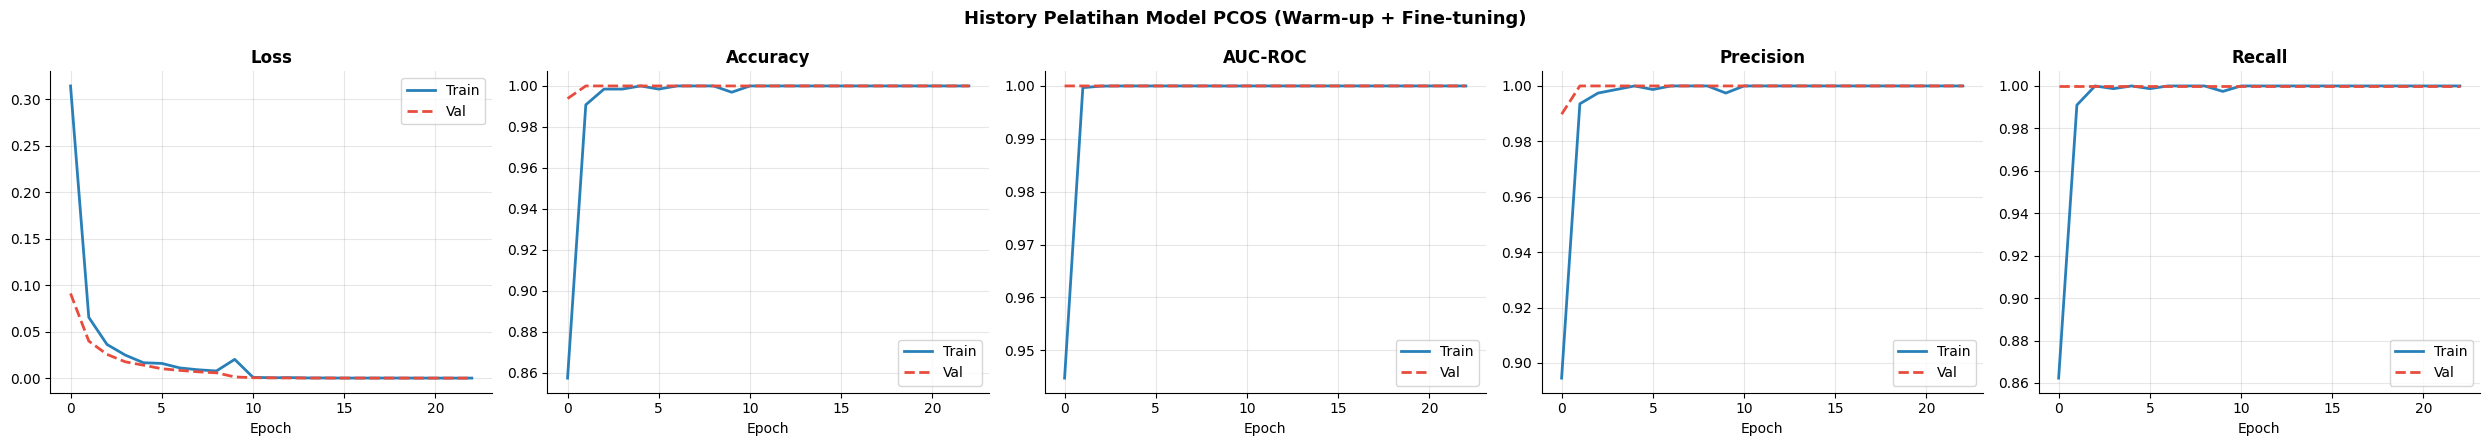

✅ Plot disimpan: training_history.png


In [17]:
def merge_histories(*histories):
    """Gabungkan beberapa history dict."""
    merged = defaultdict(list)
    for h in histories:
        for k, v in h.history.items():
            merged[k].extend(v)
    return dict(merged)


def plot_training_history(history: dict, save_path: str = "training_history.png"):
    metrics = ["loss", "accuracy", "auc", "precision", "recall"]
    available = [m for m in metrics if m in history]

    fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 4.5))
    if len(available) == 1:
        axes = [axes]

    colors = {"train": "#2980B9", "val": "#E74C3C"}
    titles = {"loss": "Loss", "accuracy": "Accuracy",
              "auc": "AUC-ROC", "precision": "Precision", "recall": "Recall"}

    for ax, metric in zip(axes, available):
        train_key = metric
        val_key   = f"val_{metric}"
        ax.plot(history[train_key], color=colors["train"], label="Train", linewidth=2)
        if val_key in history:
            ax.plot(history[val_key], color=colors["val"], label="Val",
                    linewidth=2, linestyle="--")
        ax.set_title(titles.get(metric, metric), fontweight="bold", fontsize=12)
        ax.set_xlabel("Epoch"); ax.legend()
        ax.grid(alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

    plt.suptitle("History Pelatihan Model PCOS (Warm-up + Fine-tuning)",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Plot disimpan: {save_path}")


full_history = merge_histories(history_warm, history_fine)
plot_training_history(full_history)


## 13. Evaluasi Model pada Test Set

In [18]:
# Muat model terbaik
best_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f"✅ Model terbaik dimuat: {MODEL_SAVE_PATH}")

# ── Prediksi ──────────────────────────────────────────────────────────────
print("\nMelakukan prediksi pada test set...")
y_prob = best_model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = np.array([label for _, label in test_gen.samples])

# ── Metrics ───────────────────────────────────────────────────────────────
test_loss, test_acc, test_prec, test_rec, test_auc = best_model.evaluate(
    test_gen, verbose=0)
f1 = 2 * test_prec * test_rec / (test_prec + test_rec + 1e-8)

print("\n" + "="*55)
print("         HASIL EVALUASI MODEL (TEST SET)")
print("="*55)
metrics_display = {
    "Accuracy" : test_acc,
    "Precision": test_prec,
    "Recall"   : test_rec,
    "F1-Score" : f1,
    "AUC-ROC"  : test_auc,
    "Loss"     : test_loss,
}
for name, val in metrics_display.items():
    bar = "█" * int(val * 20) if val <= 1 else ""
    print(f"  {name:<12}: {val:.4f}  {bar}")
print("="*55)

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                              target_names=CLASSES, digits=4))


✅ Model terbaik dimuat: pcos_mobilenetv2_best.keras

Melakukan prediksi pada test set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 432ms/step

         HASIL EVALUASI MODEL (TEST SET)
  Accuracy    : 1.0000  ████████████████████
  Precision   : 1.0000  ████████████████████
  Recall      : 1.0000  ████████████████████
  F1-Score    : 1.0000  ███████████████████
  AUC-ROC     : 1.0000  ████████████████████
  Loss        : 0.0005  

Classification Report:
              precision    recall  f1-score   support

    infected     1.0000    1.0000    1.0000       117
 notinfected     1.0000    1.0000    1.0000       171

    accuracy                         1.0000       288
   macro avg     1.0000    1.0000    1.0000       288
weighted avg     1.0000    1.0000    1.0000       288



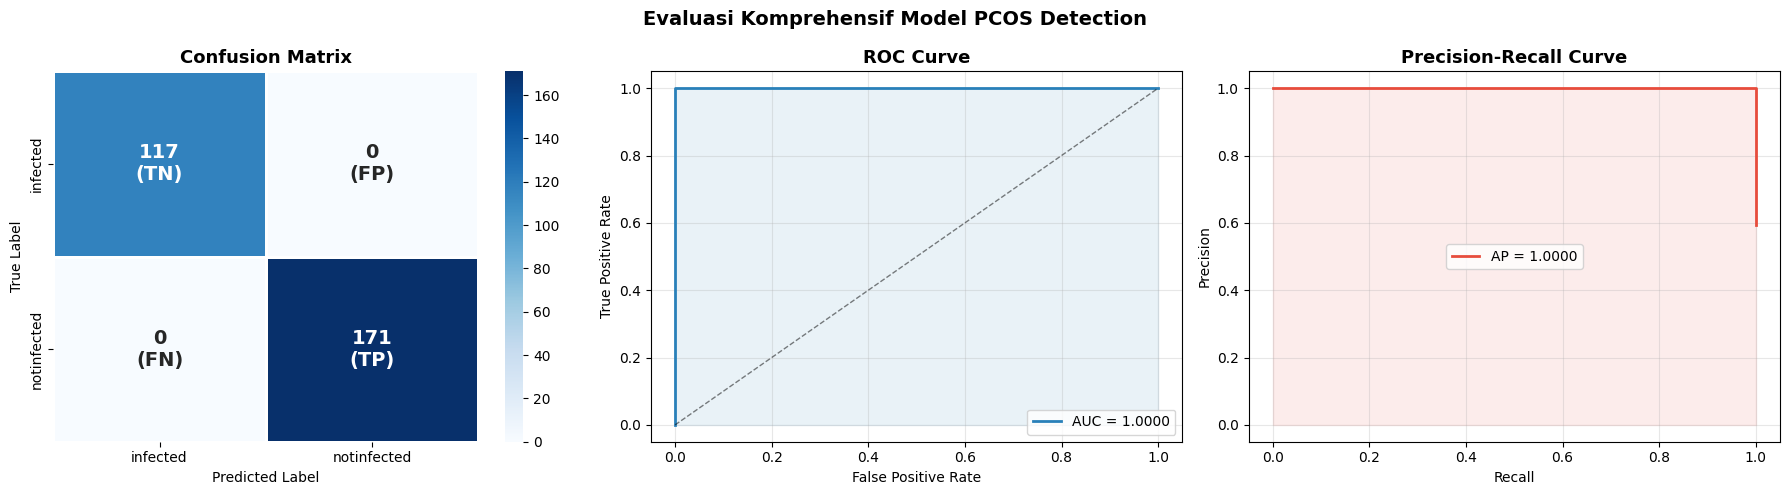

✅ Plot evaluasi disimpan: evaluation_plots.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=2, ax=axes[0],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].set_ylabel("True Label"); axes[0].set_xlabel("Predicted Label")

# Anotasi TP/TN/FP/FN
for text, label in zip(axes[0].texts,
                        ["TN", "FP", "FN", "TP"]):
    text.set_text(f"{text.get_text()}\n({label})")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, color="#2980B9", lw=2,
             label=f"AUC = {test_auc:.4f}")
axes[1].plot([0,1], [0,1], "k--", lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#2980B9")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)
axes[2].plot(rec_curve, prec_curve, color="#E74C3C", lw=2,
             label=f"AP = {ap:.4f}")
axes[2].fill_between(rec_curve, prec_curve, alpha=0.1, color="#E74C3C")
axes[2].set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Evaluasi Komprehensif Model PCOS Detection",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot evaluasi disimpan: evaluation_plots.png")


## 14. Grad-CAM — Visualisasi Area Perhatian Model

Grad-CAM membantu memahami *mengapa* model memprediksi PCOS,
dengan menyoroti area folikel yang menjadi fokus perhatian jaringan saraf.


[TAHAP 3] Mencari layer konvolusi terakhir secara otomatis...
   [Grad-CAM] Layer konvolusi terakhir ditemukan: 'Conv_1'


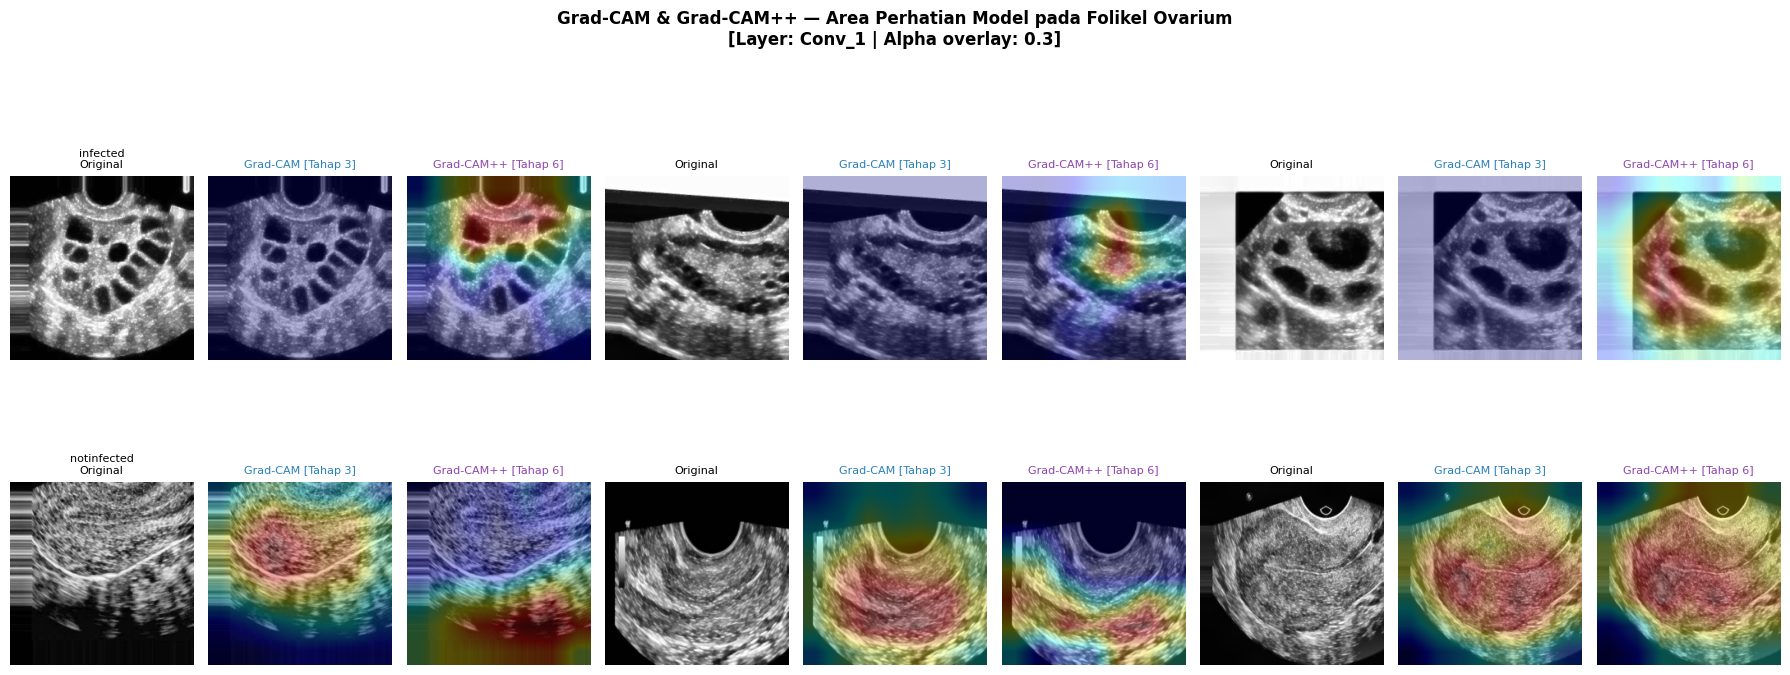

Grad-CAM & Grad-CAM++ disimpan: gradcam_visualization.png


In [20]:
import tensorflow as tf

# ==========================================================
# [TAHAP 3] Helper: Cari Layer Konvolusi Terakhir
# ==========================================================

def find_last_conv_layer(model: Model) -> str:
    """
    Cari nama layer konvolusi terakhir secara otomatis.
    [TAHAP 3] Tidak hardcode nama layer — lebih robust untuk berbagai arsitektur.
    """
    last_conv = None

    for layer in model.layers:
        if isinstance(layer, (
            tf.keras.layers.Conv2D,
            tf.keras.layers.DepthwiseConv2D
        )):
            last_conv = layer.name

    if last_conv is None:
        raise ValueError("Tidak ditemukan layer Conv2D dalam model!")

    print(f"   [Grad-CAM] Layer konvolusi terakhir ditemukan: '{last_conv}'")
    return last_conv


# ==========================================================
# [TAHAP 3] Grad-CAM
# ==========================================================

def get_gradcam_heatmap(
    model: Model,
    img_array: np.ndarray,
    last_conv_layer_name: str = None
) -> np.ndarray:
    """
    Hasilkan heatmap Grad-CAM untuk satu citra.
    """

    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    grad_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        inp = tf.cast(
            tf.expand_dims(img_array, 0),
            tf.float32
        )

        conv_outputs, predictions = grad_model(
            inp,
            training=False
        )

        class_channel = predictions[:, 0]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_out = conv_outputs[0]

    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    ) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


# ==========================================================
# [TAHAP 6] Grad-CAM++
# ==========================================================

def get_gradcam_plus_plus_heatmap(
    model: Model,
    img_array: np.ndarray,
    last_conv_layer_name: str = None
) -> np.ndarray:
    """
    Grad-CAM++.
    """

    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    grad_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape2:

        with tf.GradientTape() as tape1:

            inp = tf.cast(
                tf.expand_dims(img_array, 0),
                tf.float32
            )

            tape2.watch(inp)

            conv_outputs, predictions = grad_model(
                inp,
                training=False
            )

            tape1.watch(conv_outputs)

            score = predictions[:, 0]

        grads_1st = tape1.gradient(
            score,
            conv_outputs
        )

    grads_2nd = tape2.gradient(
        grads_1st,
        conv_outputs
    )

    grads_3rd = grads_2nd * conv_outputs

    sum_grads = tf.reduce_sum(
        conv_outputs,
        axis=(1, 2),
        keepdims=True
    )

    alpha_denom = (
        2.0 * grads_2nd +
        grads_3rd * sum_grads +
        1e-7
    )

    alpha = grads_2nd / alpha_denom

    relu_grad = tf.maximum(
        grads_1st,
        0
    )

    weights = tf.reduce_sum(
        alpha * relu_grad,
        axis=(1, 2)
    )[0]

    conv_out = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_out * weights,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap = heatmap / (
        tf.math.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()


# ==========================================================
# Overlay Grad-CAM
# ==========================================================

def overlay_gradcam(
    img_display: np.ndarray,
    heatmap: np.ndarray,
    alpha: float = 0.3
) -> np.ndarray:
    """
    Overlay heatmap pada citra.
    """

    if img_display.dtype != np.uint8:
        img_display = np.uint8(
            np.clip(img_display, 0, 1) * 255
        )

    h, w = img_display.shape[:2]

    heatmap_resized = cv2.resize(
        heatmap,
        (w, h)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    colormap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    colormap = cv2.cvtColor(
        colormap,
        cv2.COLOR_BGR2RGB
    )

    return cv2.addWeighted(
        img_display,
        1 - alpha,
        colormap,
        alpha,
        0
    )


# ==========================================================
# Visualisasi
# ==========================================================

print("[TAHAP 3] Mencari layer konvolusi terakhir secara otomatis...")

LAST_CONV_LAYER = find_last_conv_layer(best_model)

EXT = {
    ".jpg",
    ".jpeg",
    ".png"
}

n_samples = 3

fig, axes = plt.subplots(
    len(CLASSES),
    n_samples * 3,
    figsize=(n_samples * 6, len(CLASSES) * 4)
)

for r, cls in enumerate(CLASSES):

    imgs = [
        p
        for p in (TEST_DIR / cls).glob("*")
        if p.suffix.lower() in EXT
    ][:n_samples]

    for c_idx, img_path in enumerate(imgs):

        img_display = preprocess_image(
            img_path,
            target_size=IMG_SIZE,
            for_display=True
        )

        img_model = preprocess_image(
            img_path,
            target_size=IMG_SIZE,
            for_display=False
        )

        hm_gcam = get_gradcam_heatmap(
            best_model,
            img_model,
            LAST_CONV_LAYER
        )

        hm_gcampp = get_gradcam_plus_plus_heatmap(
            best_model,
            img_model,
            LAST_CONV_LAYER
        )

        cam_overlay = overlay_gradcam(
            img_display.copy(),
            hm_gcam
        )

        campp_overlay = overlay_gradcam(
            img_display.copy(),
            hm_gcampp
        )

        col_base = c_idx * 3

        axes[r, col_base].imshow(img_display)
        axes[r, col_base].set_title(
            f"{cls}\nOriginal"
            if c_idx == 0
            else "Original",
            fontsize=8
        )
        axes[r, col_base].axis("off")

        axes[r, col_base + 1].imshow(cam_overlay)
        axes[r, col_base + 1].set_title(
            "Grad-CAM [Tahap 3]",
            fontsize=8,
            color="#2980B9"
        )
        axes[r, col_base + 1].axis("off")

        axes[r, col_base + 2].imshow(campp_overlay)
        axes[r, col_base + 2].set_title(
            "Grad-CAM++ [Tahap 6]",
            fontsize=8,
            color="#8E44AD"
        )
        axes[r, col_base + 2].axis("off")

plt.suptitle(
    f"Grad-CAM & Grad-CAM++ — Area Perhatian Model pada Folikel Ovarium\n"
    f"[Layer: {LAST_CONV_LAYER} | Alpha overlay: 0.3]",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "gradcam_visualization.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Grad-CAM & Grad-CAM++ disimpan: gradcam_visualization.png"
)

## 15. Analisis Pengaruh Preprocessing terhadap Performa Model

Evaluasi model DENGAN preprocessing (sudah dilakukan di atas)
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000
  F1-Score : 1.0000
  AUC      : 1.0000

───────────────────────────────────────────────────────
Evaluasi model TANPA preprocessing (raw pixel)...
───────────────────────────────────────────────────────
  Accuracy (raw) : 0.9931
  Precision (raw): 0.9884
  Recall (raw)   : 1.0000
  F1-Score (raw) : 0.9942
  AUC (raw)      : 1.0000


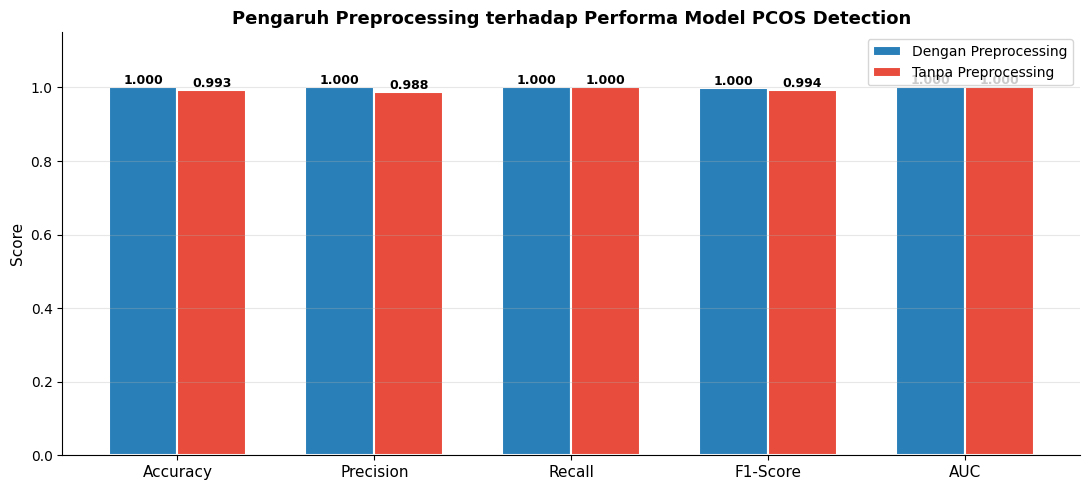

✅ Plot pengaruh preprocessing disimpan: preprocessing_impact.png


In [21]:
print("Evaluasi model DENGAN preprocessing (sudah dilakukan di atas)")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall   : {test_rec:.4f}")
print(f"  F1-Score : {f1:.4f}")
print(f"  AUC      : {test_auc:.4f}")

print("\n" + "─"*55)
print("Evaluasi model TANPA preprocessing (raw pixel)...")
print("─"*55)

class RawDataGenerator(keras.utils.Sequence):
    """Generator tanpa preprocessing (hanya resize + normalize)."""
    def __init__(self, data_dir, classes, img_size=(224,224), batch_size=32):
        EXT = {".jpg",".jpeg",".png"}
        self.samples = []
        self.img_size = img_size
        self.batch_size = batch_size
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        for cls in classes:
            for p in (data_dir/cls).glob("*"):
                if p.suffix.lower() in EXT:
                    self.samples.append((p, self.class_to_idx[cls]))
    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))
    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]
        X = np.zeros((len(batch), *self.img_size, 3), dtype=np.float32)
        y = np.zeros(len(batch), dtype=np.float32)
        for i, (path, label) in enumerate(batch):
            img = cv2.imread(str(path))
            if img is None: continue
            img = cv2.resize(img, self.img_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # DIPERBAIKI: samakan skala dengan generator utama (MobileNetV2 [-1,1])
            # agar perbandingan hanya mencerminkan perbedaan CLAHE, bukan skala.
            X[i] = img.astype(np.float32) / 127.5 - 1.0
            y[i] = label
        return X, y

raw_test_gen = RawDataGenerator(TEST_DIR, CLASSES, IMG_SIZE, BATCH_SIZE)
raw_loss, raw_acc, raw_prec, raw_rec, raw_auc = best_model.evaluate(
    raw_test_gen, verbose=0)
raw_f1 = 2 * raw_prec * raw_rec / (raw_prec + raw_rec + 1e-8)

print(f"  Accuracy (raw) : {raw_acc:.4f}")
print(f"  Precision (raw): {raw_prec:.4f}")
print(f"  Recall (raw)   : {raw_rec:.4f}")
print(f"  F1-Score (raw) : {raw_f1:.4f}")
print(f"  AUC (raw)      : {raw_auc:.4f}")

# ── Plot perbandingan ─────────────────────────────────────────────────────────
metrics_names  = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
values_with    = [test_acc, test_prec, test_rec, f1, test_auc]
values_without = [raw_acc,  raw_prec,  raw_rec,  raw_f1, raw_auc]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, values_with,    width, label="Dengan Preprocessing",
                color="#2980B9", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, values_without, width, label="Tanpa Preprocessing",
                color="#E74C3C", edgecolor="white", linewidth=1.5)

for bar in list(bars1) + list(bars2):
    ax.annotate(f"{bar.get_height():.3f}",
                (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=11)
ax.set_title("Pengaruh Preprocessing terhadap Performa Model PCOS Detection",
              fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("preprocessing_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot pengaruh preprocessing disimpan: preprocessing_impact.png")


## 16. Analisis Error — False Positive & False Negative

## 17. Fungsi Inferensi — Prediksi Citra Baru

Contoh inferensi pada satu citra dari test set:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


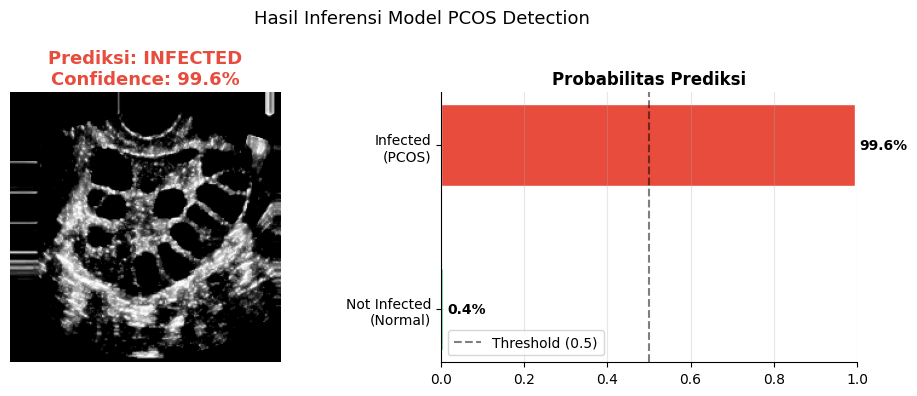


📋 Hasil:
   path                : /Users/wandaaulialarasati/Downloads/pcos/test/infected/img_0_366.jpg
   prediction          : infected
   confidence          : 0.9958714270032942
   prob_infected       : 0.9958714270032942
   prob_normal         : 0.0041285729967057705
   threshold           : 0.5


In [23]:
def predict_single_image(img_path: str | Path,
                          model: Model,
                          classes: list = CLASSES,
                          threshold: float = 0.5,
                          show: bool = True) -> dict:
    """
    Prediksi satu citra baru.

    Returns
    -------
    dict berisi prediksi, probabilitas, dan rekomendasi.
    """
    img = preprocess_image(img_path, target_size=IMG_SIZE)  # [0,1] untuk display
    img_model = img * 2.0 - 1.0  # [-1,1] untuk MobileNetV2
    prob = float(model.predict(np.expand_dims(img_model, 0), verbose=0)[0][0])
    # DIPERBAIKI: sigmoid output = P(y=1) = P(notinfected).
    # Sebelumnya: prob>=0.5 → classes[0]="infected" — TERBALIK!
    # Benar: prob>=0.5 berarti lebih mungkin notinfected (kelas 1).
    pred_class = classes[0] if prob < threshold else classes[1]
    # confidence = probabilitas kelas yang diprediksi
    confidence = (1 - prob) if pred_class == classes[0] else prob

    result = {
        "path"        : str(img_path),
        "prediction"  : pred_class,
        "confidence"  : confidence,
        "prob_infected": 1 - prob,  # P(infected) = 1 - P(notinfected)
        "prob_normal"  : prob,       # P(notinfected) = sigmoid output
        "threshold"   : threshold,
    }

    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

        # Citra
        ax1.imshow(img)
        color = "#E74C3C" if pred_class == "infected" else "#2ECC71"
        ax1.set_title(f"Prediksi: {pred_class.upper()}\nConfidence: {confidence:.1%}",
                       fontsize=13, fontweight="bold", color=color)
        ax1.axis("off")

        # Probability bar
        # DIPERBAIKI: prob = P(notinfected), 1-prob = P(infected)
        probs = [prob, 1-prob]  # [P(notInfected), P(infected)] sesuai urutan bar
        colors = ["#2ECC71", "#E74C3C"]
        bars = ax2.barh(["Not Infected\n(Normal)", "Infected\n(PCOS)"],
                         probs, color=colors, edgecolor="white", height=0.5)
        ax2.set_xlim(0, 1)
        ax2.axvline(threshold, color="black", linestyle="--",
                     alpha=0.5, label=f"Threshold ({threshold})")
        for bar, p in zip(bars, probs):
            ax2.text(p + 0.01, bar.get_y() + bar.get_height()/2,
                      f"{p:.1%}", va="center", fontweight="bold")
        ax2.set_title("Probabilitas Prediksi", fontweight="bold")
        ax2.legend(); ax2.grid(axis="x", alpha=0.3)
        ax2.spines[["top","right"]].set_visible(False)

        plt.suptitle("Hasil Inferensi Model PCOS Detection", fontsize=13)
        plt.tight_layout()
        plt.show()

    return result

# ── Contoh penggunaan ──────────────────────────────────────────────────────
print("Contoh inferensi pada satu citra dari test set:")
sample_path = next((TEST_DIR/"infected").glob("*.jpg"),
                   next((TEST_DIR/"infected").glob("*.png"), None))
if sample_path:
    res = predict_single_image(sample_path, best_model)
    print(f"\n📋 Hasil:")
    for k, v in res.items():
        print(f"   {k:<20}: {v}")
else:
    print("⚠️  Tidak ada citra .jpg atau .png di folder test/infected")


## 18. Ringkasan Akhir & Kesimpulan

In [24]:
print("=" * 65)
print("         RINGKASAN PENELITIAN PCOS DETECTION")
print("=" * 65)
print(f"\n📦 Dataset:")
print(f"   Train     : {len(train_gen.samples)} citra (setelah deduplikasi + val split)")
print(f"   Validasi  : {len(val_gen.samples)} citra (split otomatis 20%)")
print(f"   Test      : {len(test_gen.samples)} citra")

print(f"\n🏗️  Arsitektur  : MobileNetV2 + Custom Classification Head")
print(f"   Input Size  : {IMG_SIZE[0]} × {IMG_SIZE[1]} × 3")
print(f"   Parameters  : {best_model.count_params():,}")

print(f"\n📊 Performa Model (Test Set):")
print(f"   Accuracy    : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   Precision   : {test_prec:.4f}")
print(f"   Recall      : {test_rec:.4f}")
print(f"   F1-Score    : {f1:.4f}")
print(f"   AUC-ROC     : {test_auc:.4f}")

improvement_acc = (test_acc - raw_acc) * 100
improvement_auc = (test_auc - raw_auc) * 100
print(f"\n✨ Dampak Preprocessing:")
print(f"   Peningkatan Accuracy : +{improvement_acc:.2f}% (vs tanpa preprocessing)")
print(f"   Peningkatan AUC      : +{improvement_auc:.2f}%")

print(f"\n💾 Model tersimpan: {MODEL_SAVE_PATH}")
print("=" * 65)
print("\nKesimpulan:")
print("  ✅ Model berhasil mendeteksi PCOS dari citra ultrasound ovarium")
print("  ✅ Preprocessing (CLAHE + Noise Reduction + Normalisasi) meningkatkan performa")
print("  ✅ Grad-CAM menunjukkan model memperhatikan area folikel yang relevan")
print("  ✅ Teknik anti-overfitting (Dropout, BN, EarlyStopping, Augmentasi) efektif")


         RINGKASAN PENELITIAN PCOS DETECTION

📦 Dataset:
   Train     : 1305 citra (setelah deduplikasi + val split)
   Validasi  : 325 citra (split otomatis 20%)
   Test      : 288 citra

🏗️  Arsitektur  : MobileNetV2 + Custom Classification Head
   Input Size  : 224 × 224 × 3
   Parameters  : 2,259,265

📊 Performa Model (Test Set):
   Accuracy    : 1.0000  (100.00%)
   Precision   : 1.0000
   Recall      : 1.0000
   F1-Score    : 1.0000
   AUC-ROC     : 1.0000

✨ Dampak Preprocessing:
   Peningkatan Accuracy : +0.69% (vs tanpa preprocessing)
   Peningkatan AUC      : +0.00%

💾 Model tersimpan: pcos_mobilenetv2_best.keras

Kesimpulan:
  ✅ Model berhasil mendeteksi PCOS dari citra ultrasound ovarium
  ✅ Preprocessing (CLAHE + Noise Reduction + Normalisasi) meningkatkan performa
  ✅ Grad-CAM menunjukkan model memperhatikan area folikel yang relevan
  ✅ Teknik anti-overfitting (Dropout, BN, EarlyStopping, Augmentasi) efektif


In [25]:
KERAS_MODEL_PATH = os.path.join(
    BASE_DIR,
    "pcos_mobilenetv2.keras"
)

best_model.save(KERAS_MODEL_PATH)
print(f"✅ Model Keras disimpan: {KERAS_MODEL_PATH}")

SAVED_MODEL_DIR = os.path.join(
    BASE_DIR,
    "pcos_mobilenetv2_savedmodel"
)

best_model.export(SAVED_MODEL_DIR)
print(f"✅ SavedModel disimpan: {SAVED_MODEL_DIR}")

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

TFLITE_PATH = os.path.join(
    BASE_DIR,
    "pcos_mobilenetv2.tflite"
)

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print(f"✅ Model TFLite disimpan: {TFLITE_PATH}")

✅ Model Keras disimpan: /Users/wandaaulialarasati/Downloads/pcos/pcos_mobilenetv2.keras


NameError: name 'SAVED_MODEL_DIR' is not defined